In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt

def process_energy_data(filename, include_zero_mode=False):
    """
    Process energy data from especData.dat file.
    
    Parameters:
    -----------
    filename : str
        Path to the energy data file
    include_zero_mode : bool, optional
        Whether to include the zero mode (first mode) in calculations.
        Default is False (exclude zero mode).
        
    Returns:
    --------
    dict
        Dictionary containing processed energy data with keys:
        - 'times': array of time values
        - 'ke_data': 2D array of kinetic energy data
        - 'pe_data': 2D array of potential energy data  
        - 'dke_data': 2D array of kinetic energy dissipation data
        - 'total_ke': normalized total kinetic energy
        - 'total_pe': normalized total potential energy
        - 'total_energy': total energy (KE + PE)
        - 'total_dke': cumulative dissipation
        - 'time_steps': time step sizes
        - 'include_zero_mode': whether zero mode was included
    """
    # Load the data from the file
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Process the data
    i = 0
    times = []
    ke_data = []
    pe_data = []
    dke_data = []
    
    while i < len(lines):
        current_set = {}
        
        while i < len(lines):
            line = lines[i].strip()
            if line:
                parts = line.split()
                label = parts[0].rstrip(':').upper()
                time_val = float(parts[1])
                data_vals = []
                for x in parts[2:]:
                    try:
                        data_vals.append(float(x))
                    except ValueError:
                        print(f"Warning: Could not convert '{x}' to float, setting to 0.0")
                        data_vals.append(0.0)
                
                current_set[label] = {'time': time_val, 'data': data_vals}
                i += 1
                
                # Check if we have a complete set (at minimum KE, PE, DKE)
                if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
                    # Check if there's a PE2 in the next line
                    if i < len(lines):
                        next_line = lines[i].strip()
                        if next_line and next_line.split()[0].rstrip(':').upper() == 'PE2':
                            continue  # Read PE2 as well
                    break
            else:
                i += 1
        
        # Store the data from current set
        if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
            times.append(current_set['KE']['time'])
            ke_data.append(current_set['KE']['data'])
            pe_data.append(current_set['PE']['data'])
            dke_data.append(current_set['DKE']['data'])

    # Convert to numpy arrays
    ke_data = np.array(ke_data)
    pe_data = np.array(pe_data)
    dke_data = np.array(dke_data)
    times = np.array(times)

    # Calculate total energy - include or exclude zero mode based on parameter
    if include_zero_mode:
        total_ke = np.sum(ke_data, axis=1)  # Include all modes
        total_pe = np.sum(pe_data, axis=1)  # Include all modes
        total_dke_per_step = np.sum(dke_data, axis=1)  # Include all modes
    else:
        total_ke = np.sum(ke_data[:, 1:], axis=1)  # Exclude the first mode
        total_pe = np.sum(pe_data[:, 1:], axis=1)  # Exclude the first mode
        total_dke_per_step = np.sum(dke_data[:, 1:], axis=1)  # Exclude the first mode
        # total_pe = np.sum(pe_data, axis=1)  # Include all modes
        # total_dke_per_step = np.sum(dke_data, axis=1)  # Include all modes
    
    total_ke = total_ke - total_ke[0]  # Normalize kinetic energy
    total_pe = total_pe - total_pe[0]  # Normalize potential energy

    total_energy = total_ke + total_pe

    # Calculate cumulative dissipation using trapezoidal rule
    time_steps = np.diff(times)
    if len(time_steps) > 0:
        total_dke = np.zeros_like(total_dke_per_step)
        for i in range(1, len(total_dke_per_step)):
            dt = times[i] - times[i-1]
            total_dke[i] = total_dke[i-1] + 0.5 * (total_dke_per_step[i-1] + total_dke_per_step[i]) * dt
    else:
        total_dke = np.zeros_like(total_dke_per_step)    
    time_steps = np.diff(times)
    time_steps = np.append(time_steps[0] if len(time_steps) > 0 else 0, time_steps)

    mode_info = "including zero mode" if include_zero_mode else "excluding zero mode"
    print(f"Detected data types: KE, PE, DKE ({mode_info})")
    print(f"Number of time steps: {len(times)}")
    
    return {
        'times': times,
        'ke_data': ke_data,
        'pe_data': pe_data,
        'dke_data': dke_data,
        'total_ke': total_ke,
        'total_pe': total_pe,
        'total_energy': total_energy,
        'total_dke': total_dke,
        'time_steps': time_steps,
        'include_zero_mode': include_zero_mode
    }

In [2]:
def plot_power_spectrums(data, time_instant, time_tolerance=1e-6):
    """
    Plot power spectrums of KE, PE, and DKE for a specific time instant.
    
    Parameters:
    -----------
    data : dict
        Processed energy data from process_energy_data function
    time_instant : float
        Time instant to plot spectrums for
    time_tolerance : float, optional
        Tolerance for finding the closest time instant (default: 1e-6)
    """
    # Find the closest time index
    time_diffs = np.abs(data['times'] - time_instant)
    time_idx = np.argmin(time_diffs)
    
    if time_diffs[time_idx] > time_tolerance:
        print(f"Warning: Closest time found is {data['times'][time_idx]:.6f}, "
              f"which differs from requested {time_instant:.6f} by {time_diffs[time_idx]:.2e}")
    
    actual_time = data['times'][time_idx]
    
    # Extract data for this time instant
    ke_spectrum = data['ke_data'][time_idx, :]
    pe_spectrum = data['pe_data'][time_idx, :]
    dke_spectrum = data['dke_data'][time_idx, :]
    
    # Create mode numbers (assuming data is ordered by mode)
    modes = np.arange(len(ke_spectrum))
    
    # Set matplotlib to use grayscale
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['black', 'gray', 'dimgray', 'lightgray', 'darkgray'])
    
    # Create the plot
    if data['include_zero_mode']:
        fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    else:
        fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle(f'Power Spectrums at Time t = {actual_time:.6f}', fontsize=16, fontweight='bold', color='black')
    
    # KE Spectrum
    axes[0].semilogy(modes, np.abs(ke_spectrum), 'o-', color='black', linewidth=2, markersize=4)
    axes[0].set_xlabel('Mode Number', color='black')
    axes[0].set_ylabel('|KE|', color='black')
    axes[0].set_title('Kinetic Energy Spectrum', color='black')
    axes[0].grid(True, alpha=0.3, color='gray')
    axes[0].tick_params(colors='black')
    
    # PE Spectrum
    axes[1].semilogy(modes, np.abs(pe_spectrum), 's-', color='gray', linewidth=2, markersize=4)
    axes[1].set_xlabel('Mode Number', color='black')
    axes[1].set_ylabel('|PE|', color='black')
    axes[1].set_title('Potential Energy Spectrum', color='black')
    axes[1].grid(True, alpha=0.3, color='gray')
    axes[1].tick_params(colors='black')
    
    # DKE Spectrum
    axes[2].semilogy(modes, np.abs(dke_spectrum), '^-', color='dimgray', linewidth=2, markersize=4)
    axes[2].set_xlabel('Mode Number', color='black')
    axes[2].set_ylabel('|DKE|', color='black')
    axes[2].set_title('Kinetic Energy Dissipation Spectrum', color='black')
    axes[2].grid(True, alpha=0.3, color='gray')
    axes[2].tick_params(colors='black')
    
    # Style all axes
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.2)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSpectrum Statistics at t = {actual_time:.6f}:")
    print(f"KE total: {np.sum(ke_spectrum):.6e}, max: {np.max(np.abs(ke_spectrum)):.6e}")
    print(f"PE total: {np.sum(pe_spectrum):.6e}, max: {np.max(np.abs(pe_spectrum)):.6e}")
    print(f"DKE total: {np.sum(dke_spectrum):.6e}, max: {np.max(np.abs(dke_spectrum)):.6e}")

In [3]:
def plot_energy_analysis(data, time_percentage=1.0, print_table=False):
    """
    Plot comprehensive energy analysis including evolution over time, dKE analysis, and summary table.
    
    Parameters:
    -----------
    data : dict
        Processed energy data from process_energy_data function
    time_percentage : float, optional
        Percentage of total time range to plot (default: 1.0 for 100%)
    """
    # Set matplotlib to use grayscale
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['black', 'gray', 'dimgray', 'lightgray', 'darkgray'])
    
    # Extract data from the dictionary
    times = data['times']
    total_ke = data['total_ke']
    total_pe = data['total_pe']
    total_energy = data['total_energy']
    total_dke = data['total_dke']
    total_include_zero_mode = data['include_zero_mode']
    
    # Calculate time range for plotting
    time_range_custom = times[0] + time_percentage * (times[-1] - times[0])
    time_mask_custom = times <= time_range_custom
    
    print(f"Showing data up to time: {time_range_custom:.3f} ({time_percentage*100:.1f}% of total range)")

    # Define consistent line styles for each type of data
    line_styles = {
        'actual': {'linestyle': '-', 'linewidth': 5.0, 'color': 'black'},           # Solid black - main data
        'reference': {'linestyle': '-.', 'linewidth': 4.0, 'color': 'lightgray'},     # Dashed dark gray - reference/comparison
        'difference': {'linestyle': ':', 'linewidth': 6.0, 'color': 'gray'},        # Dotted gray - differences/residuals
        'negative': {'linestyle': '-.', 'linewidth': 4.0, 'color': 'lightgray'}      # Dash-dot dark gray - negative values
    }

    if total_include_zero_mode:
        fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    else:
        fig, axes = plt.subplots(1, 4, figsize=(24, 8))
    fig.suptitle(f'Energy Analysis Dashboard ({time_percentage*100:.1f}% Time Range)', fontsize=16, fontweight='bold', color='black')

    # 1. Energy Evolution Over Time
    ax1 = axes[0]
    ax1.plot(times, total_ke, label='Kinetic Energy (ΔKE)', **line_styles['actual'])
    ax1.plot(times, -total_pe, label='- Potential Energy (ΔPE)', **line_styles['negative'])
    ax1.plot(times, total_energy, label='Total Energy (ΔKE + ΔPE)', **line_styles['difference'])
    ax1.set_xlabel('Time', color='black')
    ax1.set_ylabel('Energy', color='black')
    ax1.set_title(f'Energy Evolution Over Time (Zero mode: {"Excluded" if not total_include_zero_mode else "Included"})', color='black')
    ax1.legend(frameon=True, fancybox=True, shadow=True)
    ax1.grid(True, alpha=0.3, color='gray')
    ax1.tick_params(colors='black')

    # Auto-adjust y-limits for subplot 1
    y_data_ax1 = np.concatenate([total_ke[time_mask_custom], -total_pe[time_mask_custom], total_energy[time_mask_custom]])
    y_data_ax1 = y_data_ax1[np.isfinite(y_data_ax1)]  # Remove any inf/nan values
    if len(y_data_ax1) > 0:
        y_min, y_max = np.min(y_data_ax1), np.max(y_data_ax1)
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * abs(y_max)
        ax1.set_ylim(y_min - margin, y_max + margin)

    # 2. dKE Analysis for KE
    ax2 = axes[1]
    ax2.plot(times, total_dke, label='Cumulative dKE', **line_styles['actual'])
    ax2.plot(times, total_ke-total_ke[0], label='ΔKE = KE - KE(0)', **line_styles['reference'])
    difference_ke = (total_ke - total_ke[0]) - total_dke
    ax2.plot(times, difference_ke, label='Difference: ΔKE - Cumulative dKE', **line_styles['difference'])
    ax2.set_xlabel('Time', color='black')
    ax2.set_ylabel('Energy', color='black')
    ax2.set_title(f'dKE vs KE Change Comparison (Zero mode: {"Excluded" if not total_include_zero_mode else "Included"})', color='black')
    ax2.legend(frameon=True, fancybox=True, shadow=True)
    ax2.grid(True, alpha=0.3, color='gray')
    ax2.tick_params(colors='black')

    # Auto-adjust y-limits for subplot 2
    y_data_ax2 = np.concatenate([total_dke[time_mask_custom], (total_ke-total_ke[0])[time_mask_custom], difference_ke[time_mask_custom]])
    y_data_ax2 = y_data_ax2[np.isfinite(y_data_ax2)]
    if len(y_data_ax2) > 0:
        y_min, y_max = np.min(y_data_ax2), np.max(y_data_ax2)
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * abs(y_max)
        ax2.set_ylim(y_min - margin, y_max + margin)

    # 3. dKE Analysis for PE
    ax3 = axes[2]
    ax3.plot(times, -total_dke, label='- Cumulative dKE', **line_styles['actual'])
    ax3.plot(times, total_pe, label='ΔAPE = APE - APE(0)', **line_styles['negative'])
    difference_pe = (total_pe - total_pe[0]) - (-total_dke)
    ax3.plot(times, difference_pe, label='Difference: ΔAPE + Cumulative dKE', **line_styles['difference'])
    ax3.set_xlabel('Time', color='black')
    ax3.set_ylabel('Energy', color='black')
    ax3.set_title(f'-dKE vs APE Change comparison (Zero mode: {"Excluded" if not total_include_zero_mode else "Included"})', color='black')
    ax3.legend(frameon=True, fancybox=True, shadow=True)
    ax3.grid(True, alpha=0.3, color='gray')
    ax3.tick_params(colors='black')

    # Auto-adjust y-limits for subplot 3
    y_data_ax3 = np.concatenate([-total_dke[time_mask_custom], total_pe[time_mask_custom], difference_pe[time_mask_custom]])
    y_data_ax3 = y_data_ax3[np.isfinite(y_data_ax3)]
    if len(y_data_ax3) > 0:
        y_min, y_max = np.min(y_data_ax3), np.max(y_data_ax3)
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * abs(y_max)
        ax3.set_ylim(y_min - margin, y_max + margin)

    # 4. zero-mode KE
    if not total_include_zero_mode:
        ke_data = data['ke_data'][:,0]
        dke_data = data['dke_data'][:,0]
        int_dke = np.cumsum(dke_data * data['time_steps'])
        ax4 = axes[3]
        ax4.plot(times, ke_data[time_mask_custom]-ke_data[0], label='Zero-mode KE', **line_styles['reference'])
        ax4.plot(times, int_dke[time_mask_custom], label='Cumulative dKE', **line_styles['actual'])
        ax4.set_xlabel('Time', color='black')
        ax4.set_ylabel('Energy', color='black')
        ax4.set_title('Zero-mode KE Evolution', color='black')
        ax4.legend(frameon=True, fancybox=True, shadow=True)
        ax4.grid(True, alpha=0.3, color='gray')
        ax4.tick_params(colors='black')
        
        # Calculate decay rate as percentage drop per time step
        ke_fit = ke_data[time_mask_custom]        
        if len(ke_fit) > 1 and ke_fit[0] != 0:
            percentage_losses = []
            for i in range(1, len(ke_fit)):
                if ke_fit[i-1] != 0:  # Avoid division by zero
                    loss_percent = (ke_fit[i-1] - ke_fit[i]) / ke_fit[i-1] * 100
                    percentage_losses.append(loss_percent)
            
            # Take average of all percentage losses
            if percentage_losses:
                avg_decay_rate = np.mean(percentage_losses)
                textstr = f'Avg decay rate: {avg_decay_rate:.3f}%/step'
            else:
                textstr = 'Decay rate: N/A (no valid steps)'
        else:
            textstr = 'Decay rate: N/A'
            
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
        ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, color='black')

    # Set all axes to have black spines and specified time range
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.2)
        # Set x-axis to specified percentage of time range
        ax.set_xlim(times[0], time_range_custom)

    plt.tight_layout()
    plt.show()

    if print_table:
        # Time stamp table with grayscale styling
        detailed_data = []
        for i, t in enumerate(times):
            row = {
                'Time': f'{t:.4f}',
                'KE': f'{total_ke[i]:.6e}',
                'APE': f'{total_pe[i]:.6e}',
                'Cumul. dKE': f'{total_dke[i]:.6e}',
                'Total Energy': f'{total_energy[i]:.6e}',
                'ΔKE': f'{total_ke[i] - total_ke[0]:.6e}',
                'Residual': f'{(total_ke[i] - total_ke[0]) - total_dke[i]:.6e}'
            }
            detailed_data.append(row)

        df = pd.DataFrame(detailed_data)

        styled_df = df.style.set_properties(**{
            'text-align': 'center',
            'font-size': '10px'
        }).set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#40466e'), ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
        ])

        print("\n" + "="*60)
        print("ENERGY ANALYSIS SUMMARY")
        print("="*60)
        print(f"Initial KE: {total_ke[0]:.6e}")
        print(f"Final KE: {total_ke[-1]:.6e}")
        print(f"KE Change: {total_ke[-1] - total_ke[0]:.6e}")
        print(f"Cumulative dKE: {total_dke[-1]:.6e}")
        print(f"Residual (ΔKE - Cum.dKE): {difference_ke[-1]:.6e}")
        print(f"Initial APE: {total_pe[0]:.6e}")
        print(f"Final APE: {total_pe[-1]:.6e}")
        print(f"APE Change: {total_pe[-1] - total_pe[0]:.6e}")
        print(f"Total Energy Change: {total_energy[-1] - total_energy[0]:.6e}")
        print("="*60)
        print("DETAILED ENERGY EVOLUTION TABLE")
        print("="*60)
        print(f"Total time steps: {len(times)}")
        display(styled_df)

In [4]:
def plot_energy_spectrum_evolution(data, time_instants, energy_type='KE', time_tolerance=1e-6):
    """
    Plot energy spectrums at different times on the same plot to show evolution.
    
    Parameters:
    -----------
    data : dict
        Processed energy data from process_energy_data function
    time_instants : list or array
        List of time instants to plot spectrums for
    energy_type : str, optional
        Type of energy to plot: 'KE', 'PE', or 'DKE' (default: 'KE')
    time_tolerance : float, optional
        Tolerance for finding the closest time instant (default: 1e-6)
    """
    # Validate energy type
    if energy_type.upper() not in ['KE', 'PE', 'DKE']:
        raise ValueError("energy_type must be 'KE', 'PE', or 'DKE'")
    
    energy_type = energy_type.upper()
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Store data for legend and analysis
    spectrum_data = []
    actual_times = []
    
    # Generate colors that get progressively deeper
    n_times = len(time_instants)
    if n_times == 1:
        colors = ['black']
    else:
        # Create a gradient from light gray to black
        gray_values = np.linspace(0.7, 0.0, n_times)
        colors = [str(val) for val in gray_values]
    
    for i, time_instant in enumerate(time_instants):
        # Find the closest time index
        time_diffs = np.abs(data['times'] - time_instant)
        time_idx = np.argmin(time_diffs)
        
        if time_diffs[time_idx] > time_tolerance:
            print(f"Warning: For requested time {time_instant:.6f}, closest time found is {data['times'][time_idx]:.6f}, "
                  f"difference: {time_diffs[time_idx]:.2e}")
        
        actual_time = data['times'][time_idx]
        actual_times.append(actual_time)
        
        # Extract spectrum data based on energy type
        if energy_type == 'KE':
            spectrum = data['ke_data'][time_idx, :]
            ylabel = '|KE|'
            title_prefix = 'Kinetic Energy'
        elif energy_type == 'PE':
            spectrum = data['pe_data'][time_idx, :]
            ylabel = '|PE|'
            title_prefix = 'Potential Energy'
        else:  # DKE
            spectrum = data['dke_data'][time_idx, :]
            ylabel = '|DKE|'
            title_prefix = 'Kinetic Energy Dissipation'
        
        spectrum_data.append(spectrum)
        
        # Create mode numbers
        modes = np.arange(len(spectrum))
        
        # Only add label for first and last time instants
        if i == 0:
            label = f't = {actual_time:.4f} (start)'
        elif i == n_times - 1:
            label = f't = {actual_time:.4f} (end)'
        else:
            label = None
        
        # Plot with solid line and progressively deeper color
        ax.semilogy(modes, np.abs(spectrum), 
                   linestyle='-',
                   color=colors[i],
                   linewidth=2, 
                   label=label)
    
    # Formatting
    ax.set_xlabel('Mode Number', color='black', fontsize=12)
    ax.set_ylabel(ylabel, color='black', fontsize=12)
    ax.set_title(f'{title_prefix} Spectrum Evolution', color='black', fontsize=14, fontweight='bold')
    ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=10)
    ax.grid(True, alpha=0.3, color='gray')
    ax.tick_params(colors='black')
    
    # Style the axes
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.2)
    
    plt.tight_layout()
    plt.show()
    
    return


Processing energy data K...
Detected data types: KE, PE, DKE (including zero mode)
Number of time steps: 566
Showing data up to time: 5.640 (100.0% of total range)


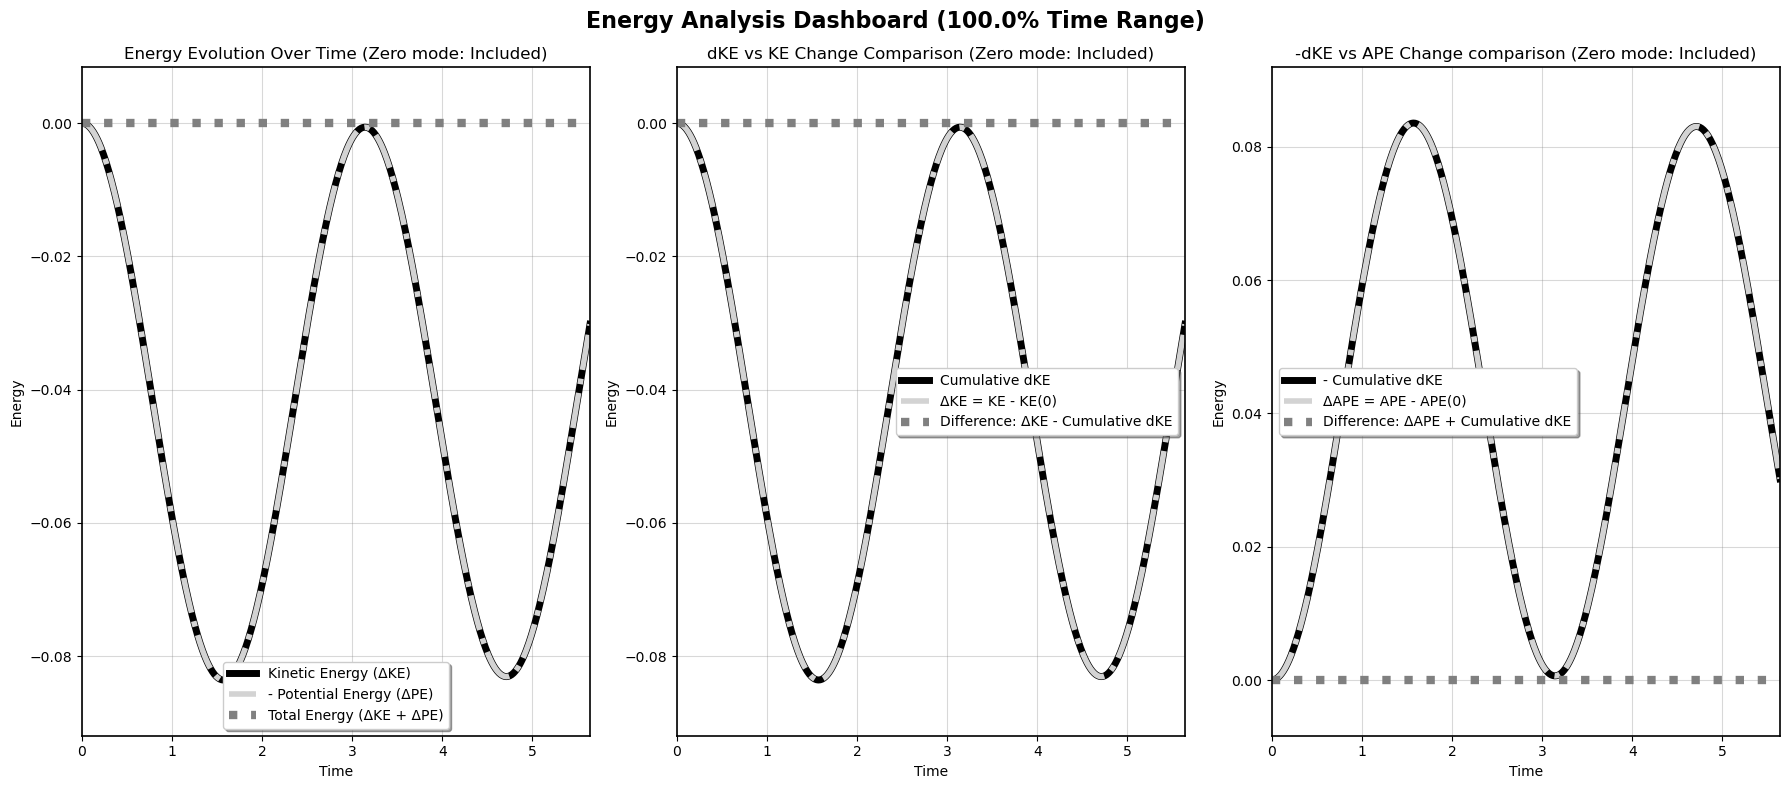

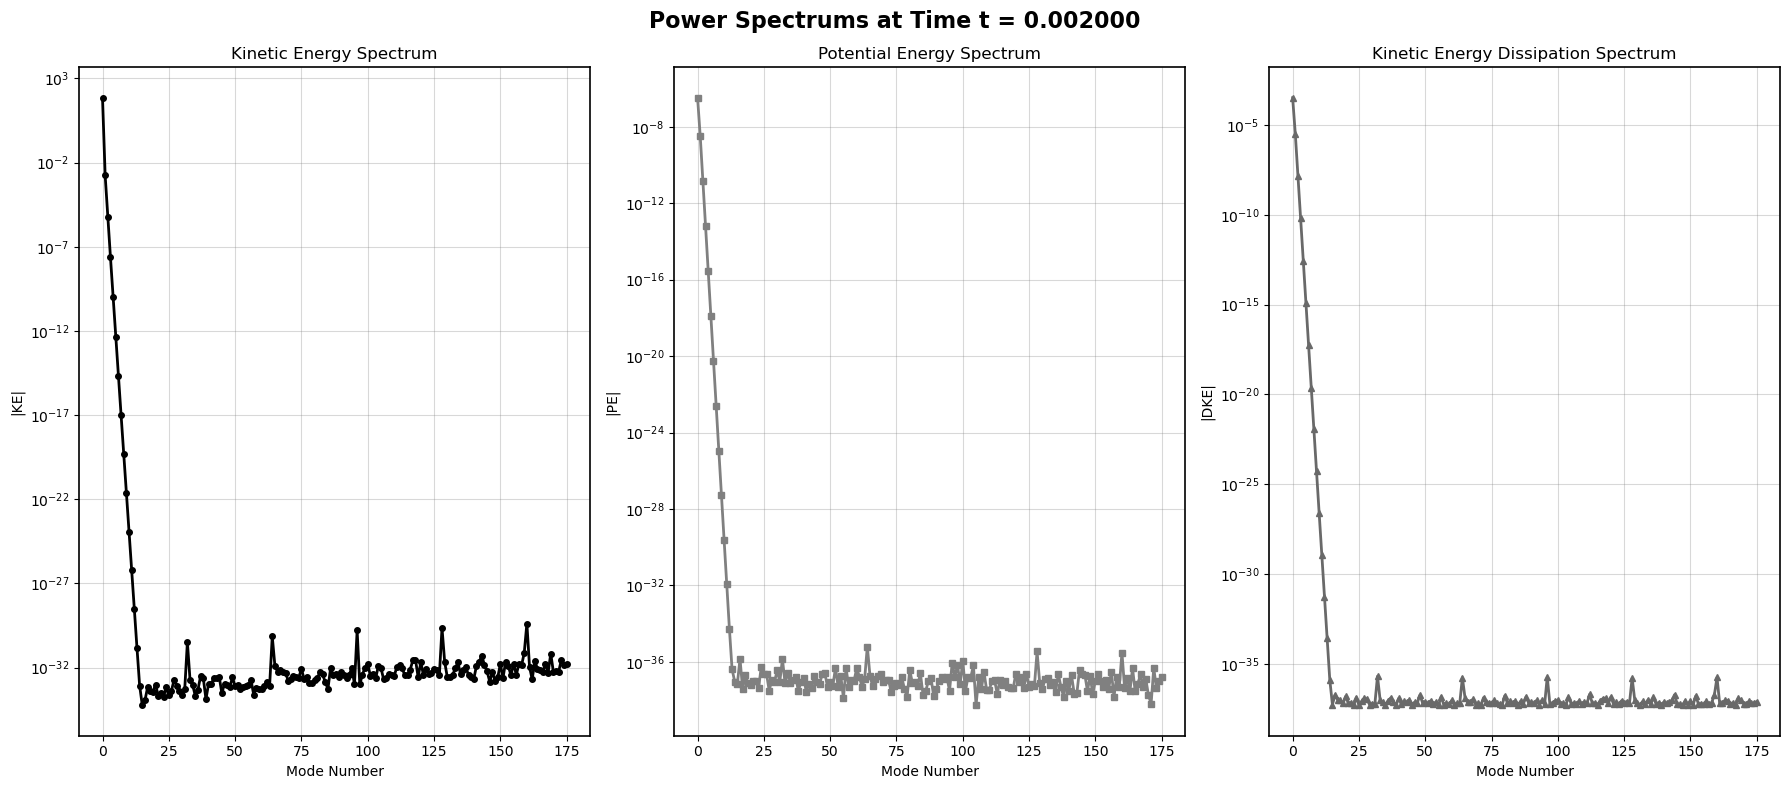


Spectrum Statistics at t = 0.002000:
KE total: 7.140273e+01, max: 7.140100e+01
PE total: 3.339838e-07, max: 3.306543e-07
DKE total: -3.339832e-04, max: 3.306538e-04


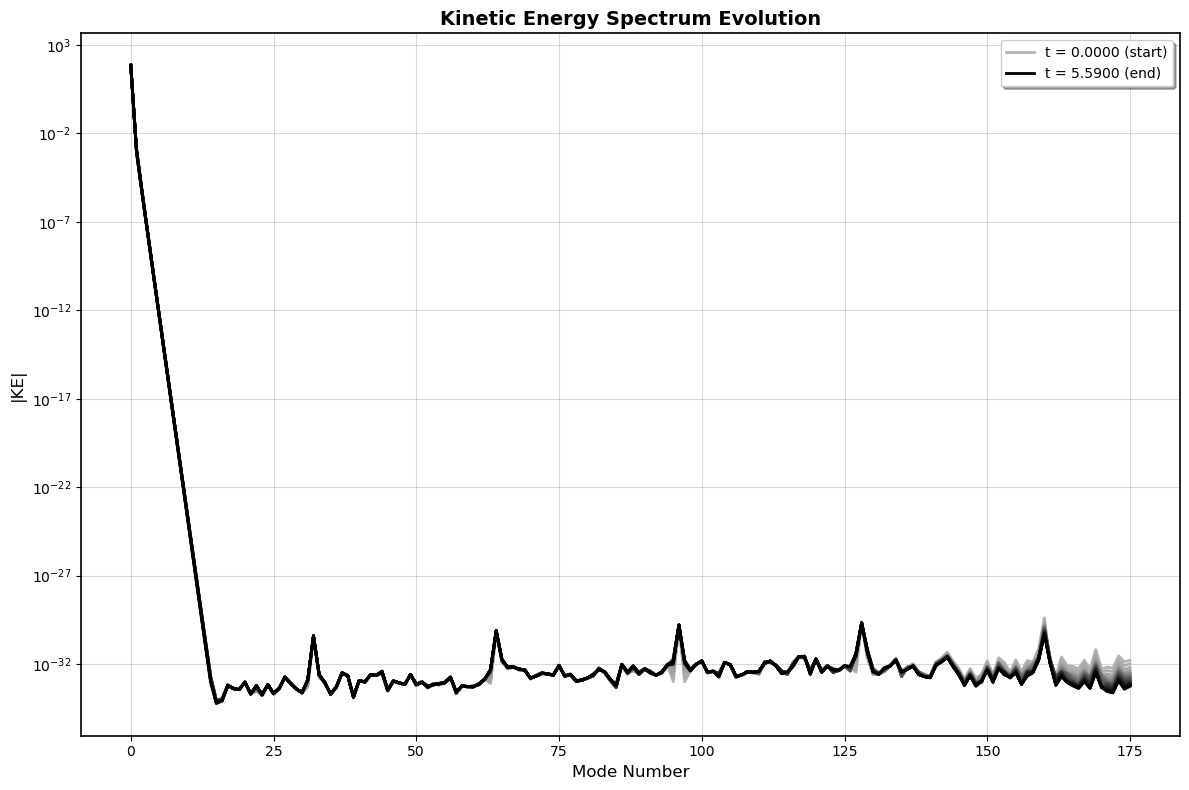

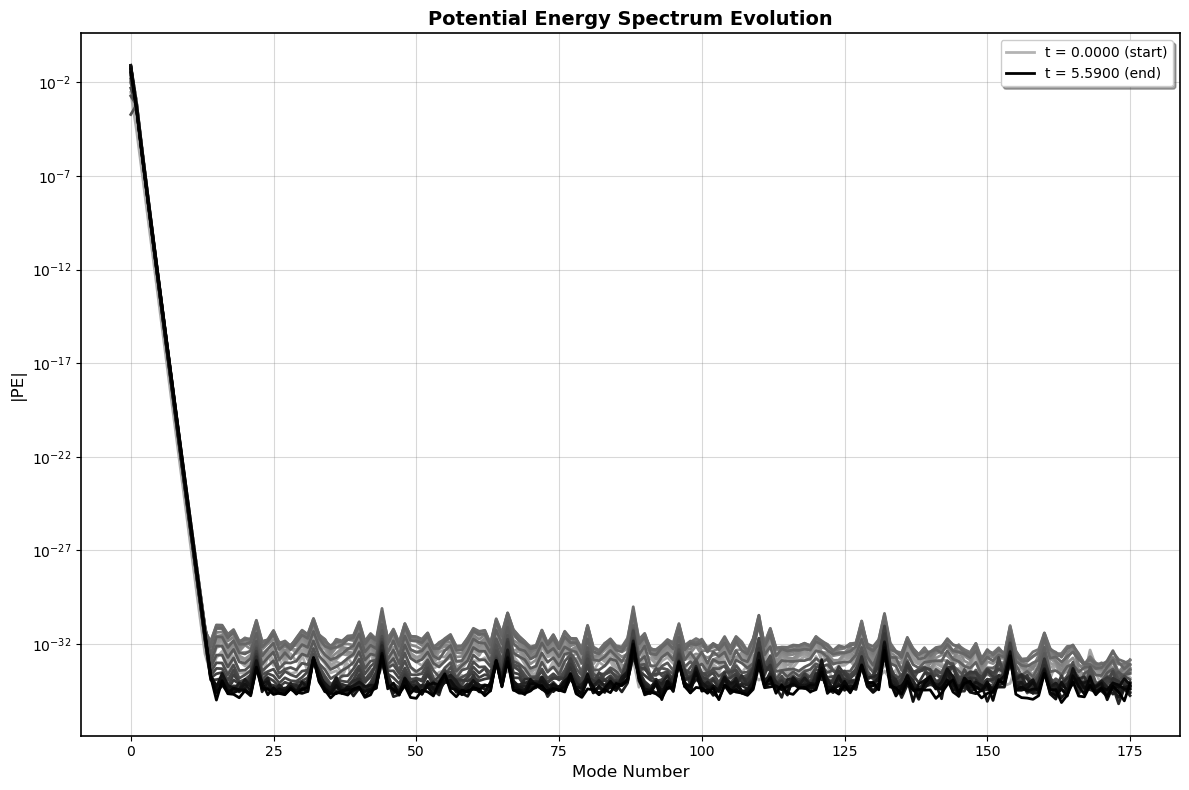

In [5]:
# Over K
print("Processing energy data K...")

energy_data_K = process_energy_data('../../output/especData_K.dat',include_zero_mode=True)
plot_energy_analysis(energy_data_K, time_percentage=1.0)
time_data_K = energy_data_K['times']
plot_power_spectrums(energy_data_K, time_instant = time_data_K[1])
plot_energy_spectrum_evolution(energy_data_K, time_data_K[::20], energy_type='KE')
plot_energy_spectrum_evolution(energy_data_K, time_data_K[::20], energy_type='PE')
# plot_energy_spectrum_evolution(energy_data_K, time_data_K[0:300], energy_type='DKE')

Processing energy data M...
Detected data types: KE, PE, DKE (including zero mode)
Number of time steps: 566
Showing data up to time: 5.640 (100.0% of total range)


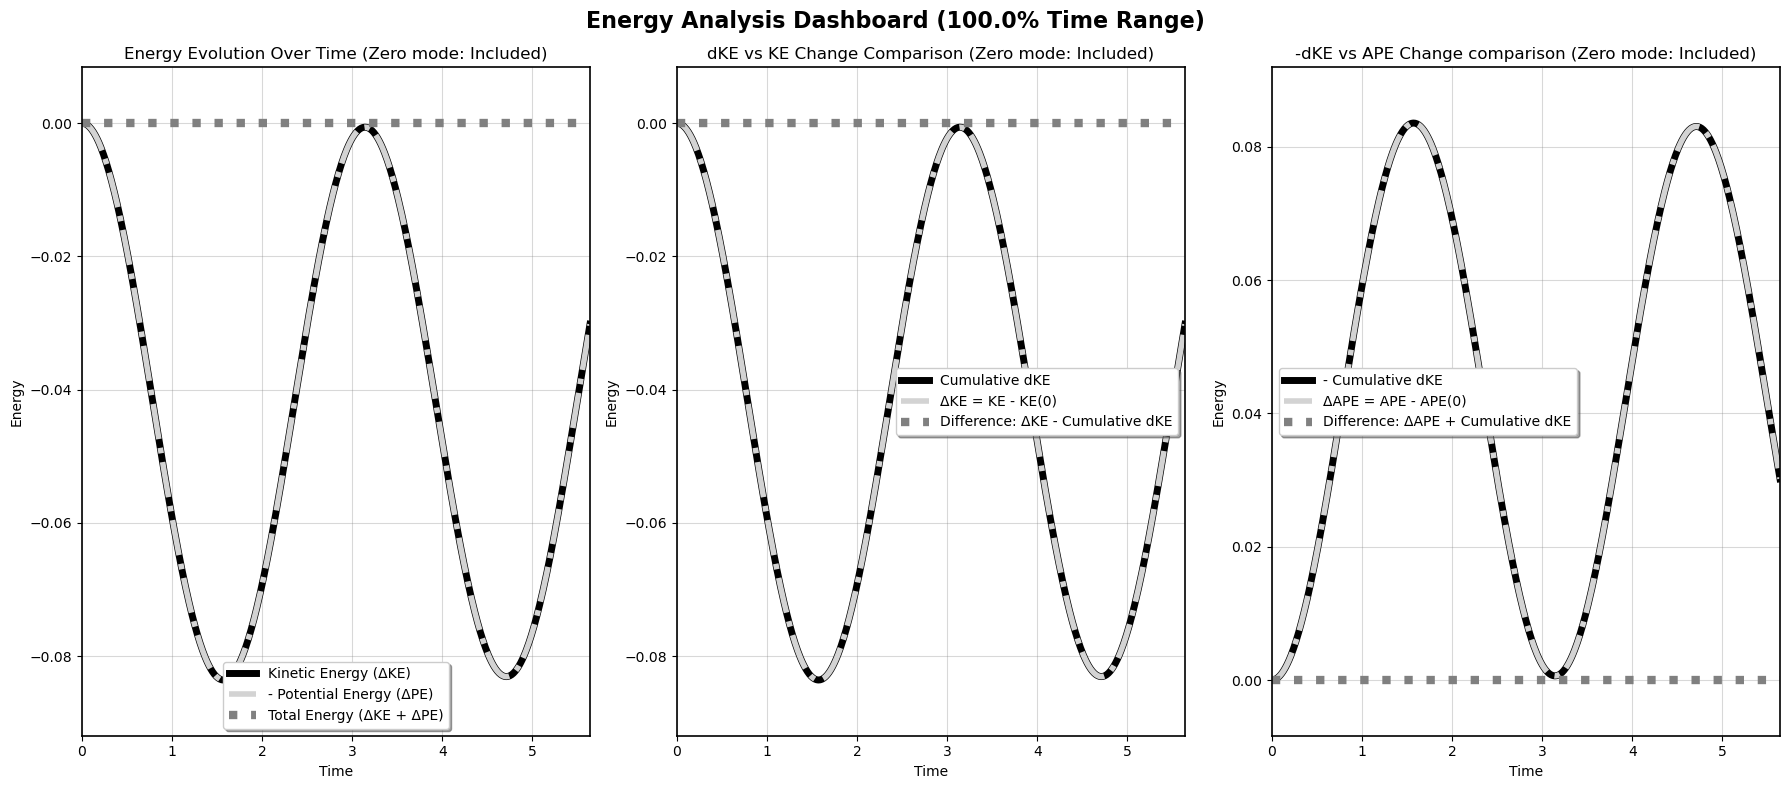

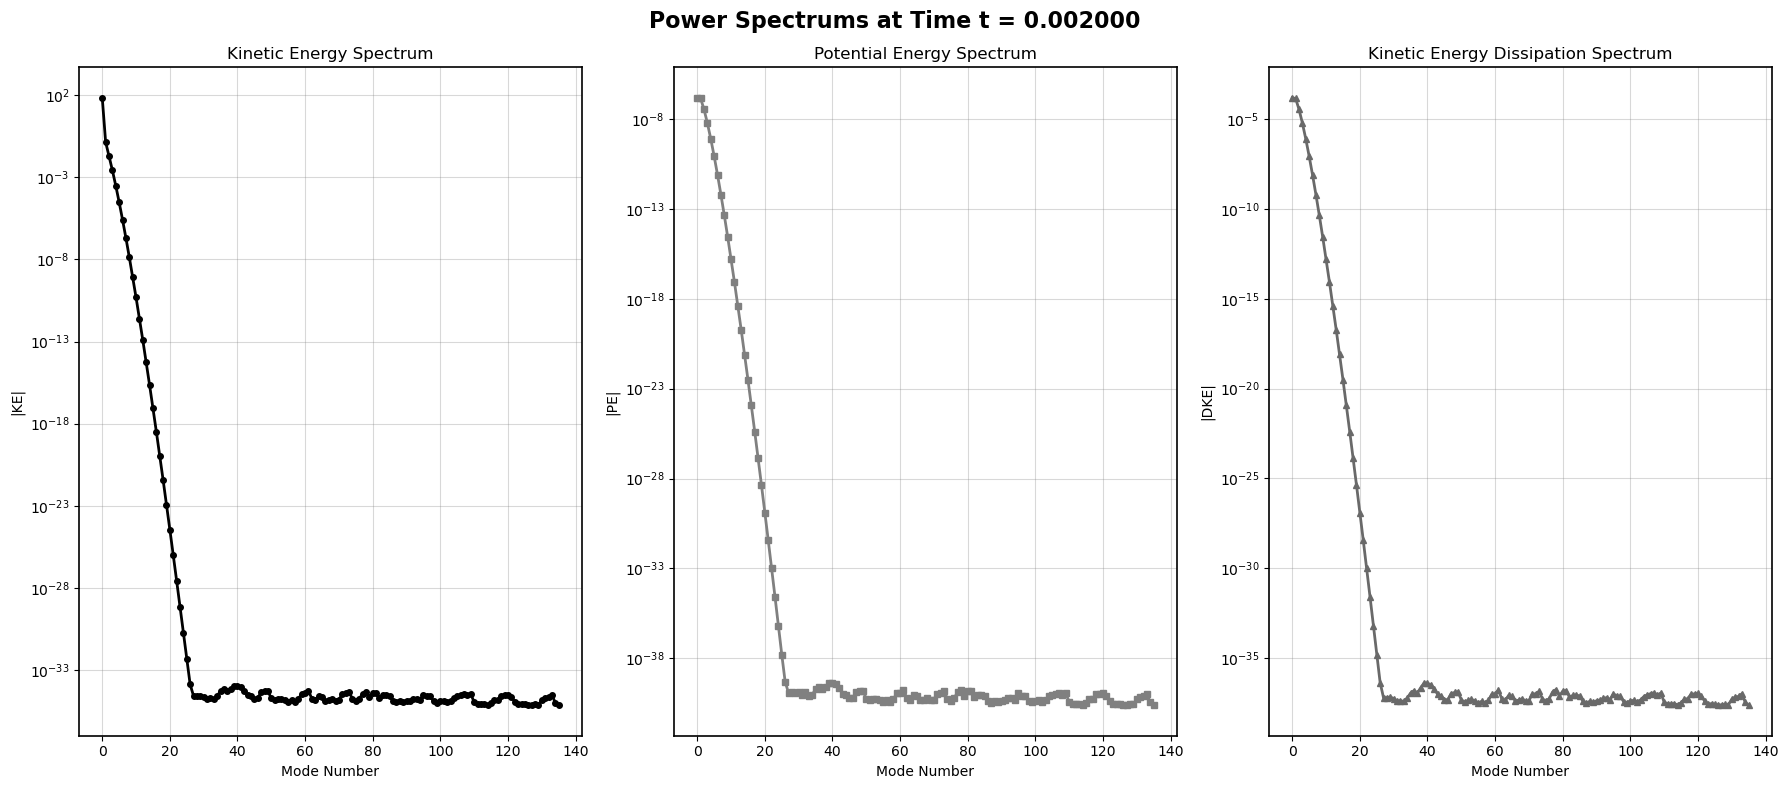


Spectrum Statistics at t = 0.002000:
KE total: 7.140273e+01, max: 7.123683e+01
PE total: 3.339838e-07, max: 1.535770e-07
DKE total: -3.339832e-04, max: 1.535768e-04


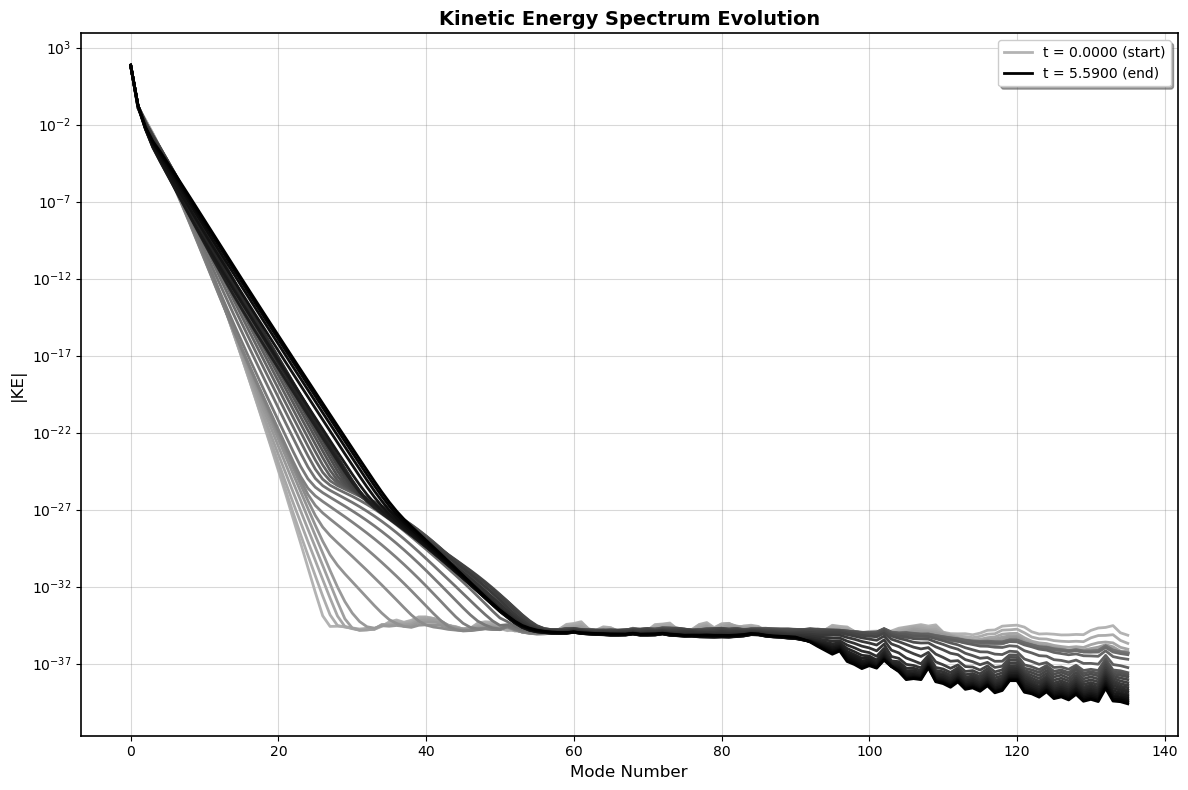

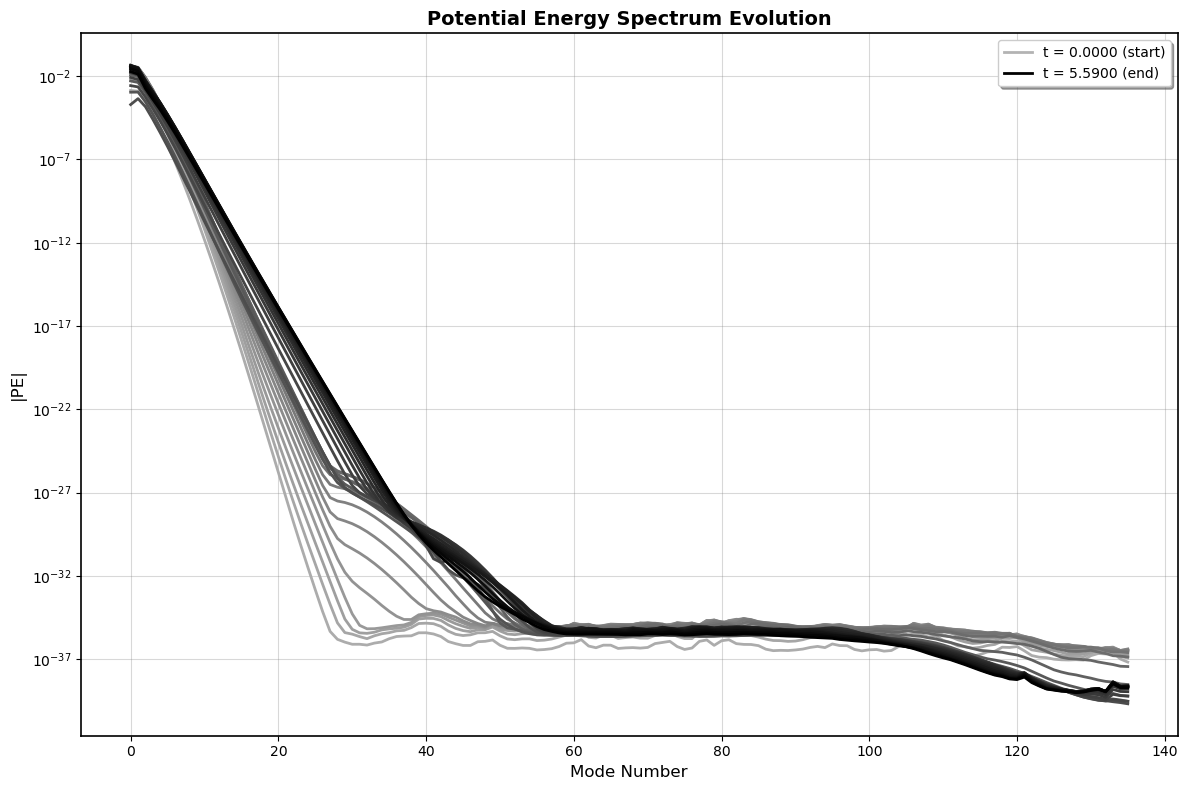

In [6]:
# over M
print("Processing energy data M...")

energy_data_M = process_energy_data('../../output/especData_M.dat',include_zero_mode=True)
plot_energy_analysis(energy_data_M, time_percentage=1.0)
time_data_M = energy_data_M['times']
plot_power_spectrums(energy_data_M, time_instant = time_data_M[1])
plot_energy_spectrum_evolution(energy_data_M, time_data_M[::20], energy_type='KE')
plot_energy_spectrum_evolution(energy_data_M, time_data_M[::20], energy_type='PE')
# plot_energy_spectrum_evolution(energy_data_M, time_data_M[0:-50], energy_type='DKE')